# import del dataset ed analisi esplorativa


In [1]:
import pandas as pd

df = pd.read_csv('obesity.csv')

X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

df.head()
# print(df.isna().mean() * 100) non ci sono valori mancanti 


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
print(df['NObeyesdad'].nunique())

7


L'analisi esplorativa ci ha permesso di vedere che per quanto riguarda la label target e' necessario effettuare encoding (anche per le features categoriche), inoltre non risultano esserci valori mancanti


In [ ]:
# Encoding della label tramite LabelEncoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = pd.Series(le.fit_transform(y), index=y.index, name='NObeyesdad')


## preprocessing

In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    random_state=42,
    stratify=y_encoded
    )

# Divisione features categoriche e numeriche
cat_features = X_train.select_dtypes(include=['object', 'bool', 'string']).columns
num_features = X_train.select_dtypes(include=['number']).columns

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='constant', fill_value='unknown')),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric" , num_pipe, num_features),
    ("categoric", cat_pipe, cat_features)
])

preprocessor.set_output(transform='pandas')

X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)


## Riduzione dimensionalita' tramite LDA

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=6)
lda.fit(X_train_processed, y_train)
lda.set_output(transform='pandas')
X_train_fin = lda.transform(X_train_processed)
X_test_fin = lda.transform(X_test_processed)

print(X_train_fin.shape)

(1794, 6)


In [6]:
# Classificatore con GridSearch e RandomForest

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid= {
    "n_estimators" : [50,100,200],
    "max_depth" : [None, 5, 10 ,15],
    "min_samples_split" : [2,5,10],
    "criterion" : ['gini', 'entropy']
}

rfc = RandomForestClassifier(random_state=42)
cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
grid=GridSearchCV(estimator=rfc, param_grid=param_grid, cv=cv, scoring='accuracy')
grid.fit(X_train_fin, y_train)



,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [7]:
best_model = grid.best_estimator_
best_params = grid.best_params_
best_score = grid.best_score_
acc_rfc_train = grid.score(X_train_fin, y_train)
acc_rfc_test = grid.score(X_test_fin, y_test)

y_pred_rfc = grid.predict(X_test_fin)
y_pred_prob_rfc = grid.predict_proba(X_test_fin)

print(f"Miglior modello: {best_model}")
print(f"Migliori parametri: {best_params}")
print(f"Miglior punteggio medio di cross-validation: {best_score}")
print(f"Train accuracy: {acc_rfc_train}")
print(f"Test accuracy: {acc_rfc_test}")


Miglior modello: RandomForestClassifier(criterion='entropy', random_state=42)
Migliori parametri: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Miglior punteggio medio di cross-validation: 0.9453649958761924
Train accuracy: 1.0
Test accuracy: 0.9369085173501577


## Implementazione rete neurale

In [8]:
import torchnn as tnn
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

class Data(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __getitem__(self, index):
        return self.X[index], self.y[index]
    def __len__(self):
        return len(self.X)

X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(X_train_fin, y_train, test_size=0.15, random_state=42, stratify=y_train) 

train_data = Data(X_train_nn, y_train_nn)
val_data = Data(X_val_nn, y_val_nn)
test_data = Data(X_test_fin, y_test)

# Dataloader

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(32,64, kernel_size=3, padding=1)
        

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.bn1 = nn.BatchNorm1d(num_features=32)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64,128)
        self.fc2 = nn.Linear(128,7)

        

    def forward(self, x):
        x = self.bn1(F.relu(self.conv1(x)))
        x = self.bn2(F.relu(self.conv2(x)))
        x = self.pool(x)                    # produce SEMPRE lunghezza 1, qualunque input
        x = torch.flatten(x, start_dim=1)   # 64 canali * 1 = 64 
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

    print("Modello caricato !")    



Modello caricato !


Epoch    1: 100%|██████████| 24/24 [00:00<00:00, 320.00it/s]


Train loss: 1.9475
Validation loss: 1.9270
Test loss: 1.9265 Accuracy:   0.17
Metrics:



Epoch    2: 100%|██████████| 24/24 [00:00<00:00, 330.28it/s]


Train loss: 1.9051
Validation loss: 1.8739
Test loss: 1.8761 Accuracy:   0.28
Metrics:



Epoch    3: 100%|██████████| 24/24 [00:00<00:00, 329.79it/s]


Train loss: 1.8661
Validation loss: 1.8214
Test loss: 1.8279 Accuracy:   0.43
Metrics:



Epoch    4: 100%|██████████| 24/24 [00:00<00:00, 309.24it/s]


Train loss: 1.8264
Validation loss: 1.7784
Test loss: 1.7886 Accuracy:   0.50
Metrics:



Epoch    5: 100%|██████████| 24/24 [00:00<00:00, 344.75it/s]


Train loss: 1.7842
Validation loss: 1.7349
Test loss: 1.7490 Accuracy:   0.51
Metrics:



Epoch    6: 100%|██████████| 24/24 [00:00<00:00, 336.99it/s]


Train loss: 1.7470
Validation loss: 1.6947
Test loss: 1.7121 Accuracy:   0.53
Metrics:



Epoch    7: 100%|██████████| 24/24 [00:00<00:00, 315.16it/s]


Train loss: 1.7057
Validation loss: 1.6458
Test loss: 1.6674 Accuracy:   0.54
Metrics:



Epoch    8: 100%|██████████| 24/24 [00:00<00:00, 310.14it/s]


Train loss: 1.6594
Validation loss: 1.6019
Test loss: 1.6275 Accuracy:   0.56
Metrics:



Epoch    9: 100%|██████████| 24/24 [00:00<00:00, 315.40it/s]


Train loss: 1.6158
Validation loss: 1.5516
Test loss: 1.5821 Accuracy:   0.57
Metrics:



Epoch   10: 100%|██████████| 24/24 [00:00<00:00, 341.58it/s]


Train loss: 1.5827
Validation loss: 1.5111
Test loss: 1.5446 Accuracy:   0.57
Metrics:



Epoch   11: 100%|██████████| 24/24 [00:00<00:00, 333.13it/s]


Train loss: 1.5383
Validation loss: 1.4604
Test loss: 1.4997 Accuracy:   0.58
Metrics:



Epoch   12: 100%|██████████| 24/24 [00:00<00:00, 338.86it/s]


Train loss: 1.4983
Validation loss: 1.4228
Test loss: 1.4652 Accuracy:   0.58
Metrics:



Epoch   13: 100%|██████████| 24/24 [00:00<00:00, 332.32it/s]


Train loss: 1.4517
Validation loss: 1.3791
Test loss: 1.4253 Accuracy:   0.60
Metrics:



Epoch   14: 100%|██████████| 24/24 [00:00<00:00, 230.02it/s]


Train loss: 1.4212
Validation loss: 1.3456
Test loss: 1.3945 Accuracy:   0.61
Metrics:



Epoch   15: 100%|██████████| 24/24 [00:00<00:00, 224.55it/s]


Train loss: 1.3887
Validation loss: 1.3079
Test loss: 1.3608 Accuracy:   0.63
Metrics:



Epoch   16: 100%|██████████| 24/24 [00:00<00:00, 265.93it/s]


Train loss: 1.3532
Validation loss: 1.2730
Test loss: 1.3286 Accuracy:   0.64
Metrics:



Epoch   17: 100%|██████████| 24/24 [00:00<00:00, 236.63it/s]


Train loss: 1.3283
Validation loss: 1.2432
Test loss: 1.3008 Accuracy:   0.66
Metrics:



Epoch   18: 100%|██████████| 24/24 [00:00<00:00, 181.79it/s]


Train loss: 1.2916
Validation loss: 1.2114
Test loss: 1.2713 Accuracy:   0.66
Metrics:



Epoch   19: 100%|██████████| 24/24 [00:00<00:00, 247.98it/s]


Train loss: 1.2738
Validation loss: 1.1841
Test loss: 1.2459 Accuracy:   0.66
Metrics:



Epoch   20: 100%|██████████| 24/24 [00:00<00:00, 282.25it/s]


Train loss: 1.2406
Validation loss: 1.1605
Test loss: 1.2232 Accuracy:   0.67
Metrics:



Epoch   21: 100%|██████████| 24/24 [00:00<00:00, 286.84it/s]


Train loss: 1.2107
Validation loss: 1.1310
Test loss: 1.1953 Accuracy:   0.67
Metrics:



Epoch   22: 100%|██████████| 24/24 [00:00<00:00, 292.66it/s]


Train loss: 1.1819
Validation loss: 1.1058
Test loss: 1.1707 Accuracy:   0.68
Metrics:



Epoch   23: 100%|██████████| 24/24 [00:00<00:00, 248.59it/s]


Train loss: 1.1600
Validation loss: 1.0738
Test loss: 1.1411 Accuracy:   0.68
Metrics:



Epoch   24: 100%|██████████| 24/24 [00:00<00:00, 223.24it/s]


Train loss: 1.1373
Validation loss: 1.0541
Test loss: 1.1219 Accuracy:   0.70
Metrics:



Epoch   25: 100%|██████████| 24/24 [00:00<00:00, 165.68it/s]


Train loss: 1.1035
Validation loss: 1.0264
Test loss: 1.0952 Accuracy:   0.70
Metrics:



Epoch   26: 100%|██████████| 24/24 [00:00<00:00, 276.83it/s]


Train loss: 1.0844
Validation loss: 1.0011
Test loss: 1.0711 Accuracy:   0.71
Metrics:



Epoch   27: 100%|██████████| 24/24 [00:00<00:00, 231.78it/s]


Train loss: 1.0576
Validation loss: 0.9739
Test loss: 1.0445 Accuracy:   0.72
Metrics:



Epoch   28: 100%|██████████| 24/24 [00:00<00:00, 212.11it/s]


Train loss: 1.0328
Validation loss: 0.9537
Test loss: 1.0240 Accuracy:   0.72
Metrics:



Epoch   29: 100%|██████████| 24/24 [00:00<00:00, 169.92it/s]


Train loss: 1.0122
Validation loss: 0.9306
Test loss: 1.0011 Accuracy:   0.73
Metrics:



Epoch   30: 100%|██████████| 24/24 [00:00<00:00, 164.91it/s]


Train loss: 0.9860
Validation loss: 0.9074
Test loss: 0.9793 Accuracy:   0.74
Metrics:



Epoch   31: 100%|██████████| 24/24 [00:00<00:00, 172.38it/s]


Train loss: 0.9607
Validation loss: 0.8815
Test loss: 0.9533 Accuracy:   0.73
Metrics:



Epoch   32: 100%|██████████| 24/24 [00:00<00:00, 252.68it/s]


Train loss: 0.9368
Validation loss: 0.8593
Test loss: 0.9315 Accuracy:   0.74
Metrics:



Epoch   33: 100%|██████████| 24/24 [00:00<00:00, 217.73it/s]


Train loss: 0.9184
Validation loss: 0.8394
Test loss: 0.9113 Accuracy:   0.74
Metrics:



Epoch   34: 100%|██████████| 24/24 [00:00<00:00, 185.96it/s]


Train loss: 0.8920
Validation loss: 0.8181
Test loss: 0.8894 Accuracy:   0.73
Metrics:



Epoch   35: 100%|██████████| 24/24 [00:00<00:00, 178.25it/s]


Train loss: 0.8780
Validation loss: 0.7950
Test loss: 0.8676 Accuracy:   0.74
Metrics:



Epoch   36: 100%|██████████| 24/24 [00:00<00:00, 170.60it/s]


Train loss: 0.8529
Validation loss: 0.7761
Test loss: 0.8478 Accuracy:   0.74
Metrics:



Epoch   37: 100%|██████████| 24/24 [00:00<00:00, 230.14it/s]


Train loss: 0.8342
Validation loss: 0.7566
Test loss: 0.8272 Accuracy:   0.74
Metrics:



Epoch   38: 100%|██████████| 24/24 [00:00<00:00, 242.82it/s]


Train loss: 0.8168
Validation loss: 0.7399
Test loss: 0.8105 Accuracy:   0.77
Metrics:



Epoch   39: 100%|██████████| 24/24 [00:00<00:00, 210.01it/s]


Train loss: 0.7908
Validation loss: 0.7243
Test loss: 0.7935 Accuracy:   0.76
Metrics:



Epoch   40: 100%|██████████| 24/24 [00:00<00:00, 188.79it/s]


Train loss: 0.7788
Validation loss: 0.7061
Test loss: 0.7763 Accuracy:   0.76
Metrics:



Epoch   41: 100%|██████████| 24/24 [00:00<00:00, 197.16it/s]


Train loss: 0.7560
Validation loss: 0.6867
Test loss: 0.7560 Accuracy:   0.76
Metrics:



Epoch   42: 100%|██████████| 24/24 [00:00<00:00, 199.91it/s]


Train loss: 0.7520
Validation loss: 0.6741
Test loss: 0.7428 Accuracy:   0.76
Metrics:



Epoch   43: 100%|██████████| 24/24 [00:00<00:00, 271.86it/s]


Train loss: 0.7272
Validation loss: 0.6575
Test loss: 0.7263 Accuracy:   0.76
Metrics:



Epoch   44: 100%|██████████| 24/24 [00:00<00:00, 183.85it/s]


Train loss: 0.7211
Validation loss: 0.6438
Test loss: 0.7124 Accuracy:   0.77
Metrics:



Epoch   45: 100%|██████████| 24/24 [00:00<00:00, 188.20it/s]


Train loss: 0.7076
Validation loss: 0.6319
Test loss: 0.6990 Accuracy:   0.78
Metrics:



Epoch   46: 100%|██████████| 24/24 [00:00<00:00, 192.63it/s]


Train loss: 0.6942
Validation loss: 0.6199
Test loss: 0.6858 Accuracy:   0.78
Metrics:



Epoch   47: 100%|██████████| 24/24 [00:00<00:00, 279.81it/s]


Train loss: 0.6783
Validation loss: 0.6077
Test loss: 0.6731 Accuracy:   0.78
Metrics:



Epoch   48: 100%|██████████| 24/24 [00:00<00:00, 251.03it/s]


Train loss: 0.6675
Validation loss: 0.5964
Test loss: 0.6612 Accuracy:   0.77
Metrics:



Epoch   49: 100%|██████████| 24/24 [00:00<00:00, 172.65it/s]


Train loss: 0.6609
Validation loss: 0.5846
Test loss: 0.6477 Accuracy:   0.78
Metrics:



Epoch   50: 100%|██████████| 24/24 [00:00<00:00, 214.30it/s]


Train loss: 0.6500
Validation loss: 0.5716
Test loss: 0.6352 Accuracy:   0.78
Metrics:



Epoch   51: 100%|██████████| 24/24 [00:00<00:00, 171.48it/s]


Train loss: 0.6317
Validation loss: 0.5648
Test loss: 0.6275 Accuracy:   0.78
Metrics:



Epoch   52: 100%|██████████| 24/24 [00:00<00:00, 293.68it/s]


Train loss: 0.6188
Validation loss: 0.5545
Test loss: 0.6166 Accuracy:   0.79
Metrics:



Epoch   53: 100%|██████████| 24/24 [00:00<00:00, 265.48it/s]


Train loss: 0.6099
Validation loss: 0.5463
Test loss: 0.6081 Accuracy:   0.79
Metrics:



Epoch   54: 100%|██████████| 24/24 [00:00<00:00, 217.13it/s]


Train loss: 0.5933
Validation loss: 0.5385
Test loss: 0.6001 Accuracy:   0.80
Metrics:



Epoch   55: 100%|██████████| 24/24 [00:00<00:00, 184.79it/s]


Train loss: 0.5892
Validation loss: 0.5263
Test loss: 0.5876 Accuracy:   0.79
Metrics:



Epoch   56: 100%|██████████| 24/24 [00:00<00:00, 258.92it/s]


Train loss: 0.5729
Validation loss: 0.5204
Test loss: 0.5798 Accuracy:   0.79
Metrics:



Epoch   57: 100%|██████████| 24/24 [00:00<00:00, 259.83it/s]


Train loss: 0.5825
Validation loss: 0.5115
Test loss: 0.5709 Accuracy:   0.79
Metrics:



Epoch   58: 100%|██████████| 24/24 [00:00<00:00, 169.12it/s]


Train loss: 0.5629
Validation loss: 0.5047
Test loss: 0.5631 Accuracy:   0.80
Metrics:



Epoch   59: 100%|██████████| 24/24 [00:00<00:00, 235.02it/s]


Train loss: 0.5530
Validation loss: 0.4953
Test loss: 0.5553 Accuracy:   0.80
Metrics:



Epoch   60: 100%|██████████| 24/24 [00:00<00:00, 171.06it/s]


Train loss: 0.5602
Validation loss: 0.4910
Test loss: 0.5483 Accuracy:   0.80
Metrics:



Epoch   61: 100%|██████████| 24/24 [00:00<00:00, 176.99it/s]


Train loss: 0.5325
Validation loss: 0.4825
Test loss: 0.5370 Accuracy:   0.81
Metrics:



Epoch   62: 100%|██████████| 24/24 [00:00<00:00, 174.40it/s]


Train loss: 0.5306
Validation loss: 0.4761
Test loss: 0.5308 Accuracy:   0.81
Metrics:



Epoch   63: 100%|██████████| 24/24 [00:00<00:00, 198.67it/s]


Train loss: 0.5373
Validation loss: 0.4737
Test loss: 0.5277 Accuracy:   0.82
Metrics:



Epoch   64: 100%|██████████| 24/24 [00:00<00:00, 199.24it/s]


Train loss: 0.5203
Validation loss: 0.4674
Test loss: 0.5215 Accuracy:   0.81
Metrics:



Epoch   65: 100%|██████████| 24/24 [00:00<00:00, 221.91it/s]


Train loss: 0.5160
Validation loss: 0.4558
Test loss: 0.5125 Accuracy:   0.81
Metrics:



Epoch   66: 100%|██████████| 24/24 [00:00<00:00, 192.81it/s]


Train loss: 0.5060
Validation loss: 0.4523
Test loss: 0.5051 Accuracy:   0.81
Metrics:



Epoch   67: 100%|██████████| 24/24 [00:00<00:00, 285.59it/s]


Train loss: 0.5065
Validation loss: 0.4477
Test loss: 0.4972 Accuracy:   0.82
Metrics:



Epoch   68: 100%|██████████| 24/24 [00:00<00:00, 213.08it/s]


Train loss: 0.5016
Validation loss: 0.4400
Test loss: 0.4926 Accuracy:   0.83
Metrics:



Epoch   69: 100%|██████████| 24/24 [00:00<00:00, 226.19it/s]


Train loss: 0.4883
Validation loss: 0.4353
Test loss: 0.4887 Accuracy:   0.82
Metrics:



Epoch   70: 100%|██████████| 24/24 [00:00<00:00, 219.24it/s]


Train loss: 0.4942
Validation loss: 0.4283
Test loss: 0.4779 Accuracy:   0.82
Metrics:



Epoch   71: 100%|██████████| 24/24 [00:00<00:00, 237.10it/s]


Train loss: 0.4780
Validation loss: 0.4222
Test loss: 0.4731 Accuracy:   0.82
Metrics:



Epoch   72: 100%|██████████| 24/24 [00:00<00:00, 245.92it/s]


Train loss: 0.4804
Validation loss: 0.4223
Test loss: 0.4739 Accuracy:   0.84
Metrics:



Epoch   73: 100%|██████████| 24/24 [00:00<00:00, 184.91it/s]


Train loss: 0.4893
Validation loss: 0.4166
Test loss: 0.4684 Accuracy:   0.84
Metrics:



Epoch   74: 100%|██████████| 24/24 [00:00<00:00, 226.37it/s]


Train loss: 0.4630
Validation loss: 0.4115
Test loss: 0.4605 Accuracy:   0.83
Metrics:



Epoch   75: 100%|██████████| 24/24 [00:00<00:00, 221.32it/s]


Train loss: 0.4594
Validation loss: 0.4057
Test loss: 0.4542 Accuracy:   0.83
Metrics:



Epoch   76: 100%|██████████| 24/24 [00:00<00:00, 253.51it/s]


Train loss: 0.4655
Validation loss: 0.4010
Test loss: 0.4494 Accuracy:   0.85
Metrics:



Epoch   77: 100%|██████████| 24/24 [00:00<00:00, 215.45it/s]


Train loss: 0.4574
Validation loss: 0.3994
Test loss: 0.4465 Accuracy:   0.85
Metrics:



Epoch   78: 100%|██████████| 24/24 [00:00<00:00, 243.66it/s]


Train loss: 0.4358
Validation loss: 0.3948
Test loss: 0.4429 Accuracy:   0.84
Metrics:



Epoch   79: 100%|██████████| 24/24 [00:00<00:00, 204.87it/s]


Train loss: 0.4439
Validation loss: 0.3874
Test loss: 0.4369 Accuracy:   0.85
Metrics:



Epoch   80: 100%|██████████| 24/24 [00:00<00:00, 265.89it/s]


Train loss: 0.4338
Validation loss: 0.3849
Test loss: 0.4329 Accuracy:   0.85
Metrics:



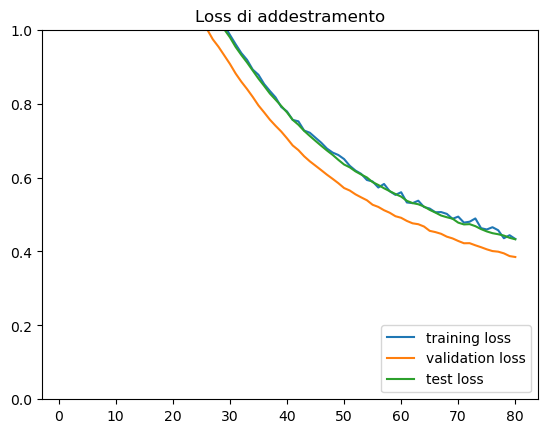

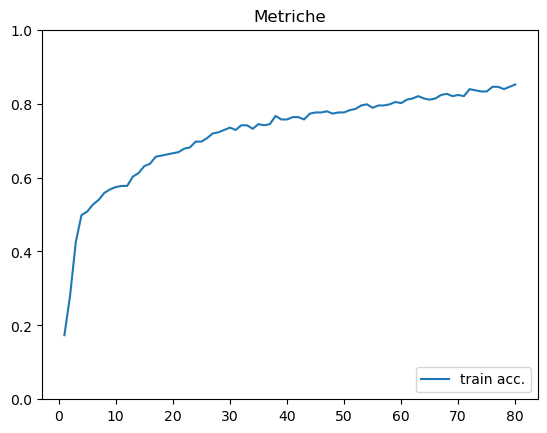

In [12]:
# Train del modello

# Carichiamo il modello nel device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Net().to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.8)
loss_fn = nn.CrossEntropyLoss()
early_stopping = tnn.EarlyStopping(patience=5, min_delta=0.001)
# scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1, end_factor=0, total_iters=epochs)

train_loss, validation_loss, test_loss, accuracy, test_metrics = tnn.train_test(
    model=model,
    optimizer=optimizer,
    early_stopping=early_stopping,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    val_dataloader=val_loader,
    device=device,
    epochs=80,
    train_loss_fn=loss_fn,
    test_loss_fn=loss_fn,
    metrics=[],
    average='micro'
)

tnn.displayLosses(train_loss, test_loss, validation_loss)
tnn.displayMetrics(accuracy, test_metrics)

tnn.save_model(
    net=model,
    optimizer=optimizer,
    current_epoch=len(train_loss),
    train_loss=train_loss,
    val_loss=validation_loss,
    test_loss=test_loss,
    accuracy=accuracy, metrics=test_metrics,
    path="best_conv1d.pt"
)


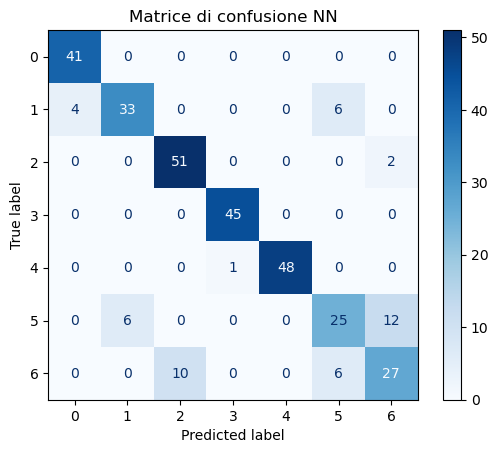

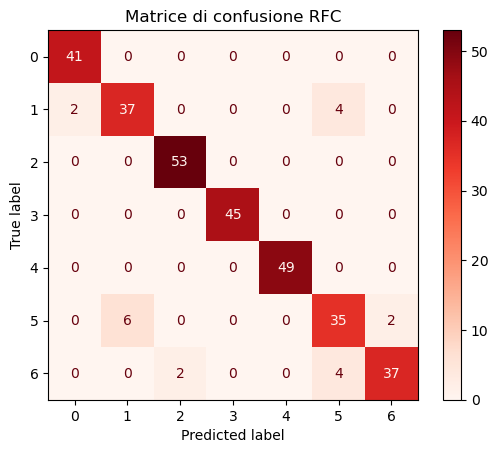

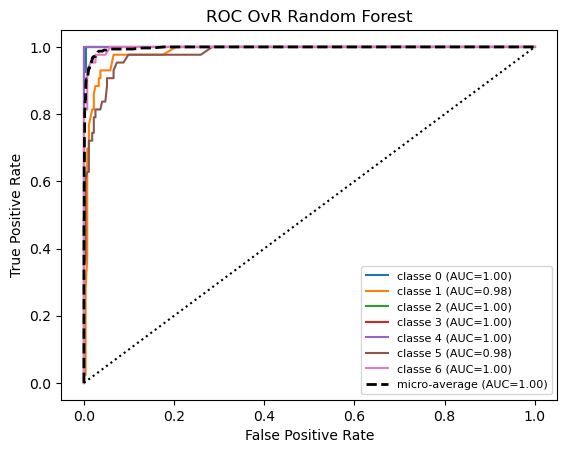

ROC OvR Random Forest: AUC micro=0.997  AUC macro=0.994


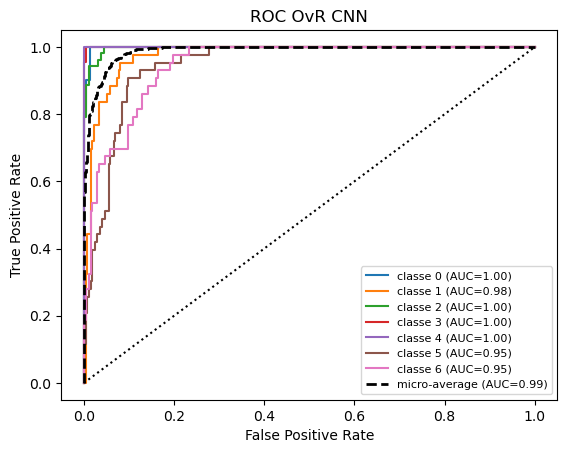

ROC OvR CNN: AUC micro=0.989  AUC macro=0.981


In [ ]:
# Confronto dei risultati

from sklearn.metrics import accuracy_score, roc_auc_score

def valuate (model, loss_fn, dataloader):

    model.eval()

    y_true, y_pred, y_prob, losses = [],[],[],[]
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Previsioni
            logits = model(X_batch)

            # Calcoliamo loss e pred
            loss=loss_fn(logits, y_batch)
            losses.append(loss.item())

            # Funzione softmax per probabilita'
            prob=torch.softmax(logits, dim=1)
            pred=torch.argmax(prob, dim=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
            y_prob.extend(prob.cpu().numpy())

        loss_media = np.mean(losses)
        acc_nn = accuracy_score(y_true, y_pred)
    return loss_media, acc_nn, y_true, y_pred, y_prob

best_model, optimizer, checkpoint = tnn.load_model("best_conv1d.pt", model=model, optimizer=optimizer, device=device)

loss_media, acc_nn, y_true_nn, y_pred_nn, y_prob_nn = valuate(best_model, loss_fn, test_loader)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm_nn=confusion_matrix.from_predictions(y_true_nn, y_pred_nn)
dis1=ConfusionMatrixDisplay(cm_nn)
dis1.plot(cmap='Blues')
plt.title("Matrice di confusione NN")
plt.show()

cm_rfc=confusion_matrix(y_test, y_pred_rfc)
dis2=ConfusionMatrixDisplay(cm_rfc)
dis2.plot(cmap='Reds')
plt.title("Matrice di confusione RFC")
plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = 7
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))  # stesso encoding per RF e NN

def plot_roc_ovr(y_true_bin, y_proba, title):
    y_proba = np.array(y_proba)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # curva micro-average: appiattisci tutto e ricalcola un'unica curva
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f"classe {i} (AUC={roc_auc[i]:.2f})")
    plt.plot(fpr["micro"], tpr["micro"], "--", color="black", linewidth=2,
              label=f"micro-average (AUC={roc_auc['micro']:.2f})")
    plt.plot([0,1],[0,1], "k:")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.legend(fontsize=8); plt.title(title)
    plt.show()

    auc_micro = roc_auc_score(y_true_bin, y_proba, average="micro")
    auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro")
    print(f"{title}: AUC micro={auc_micro:.3f}  AUC macro={auc_macro:.3f}")

plot_roc_ovr(y_test_bin, y_pred_prob_rfc,"ROC OvR Random Forest" )
plot_roc_ovr(y_test_bin, y_prob_nn,"ROC OvR CNN")